Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 51 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

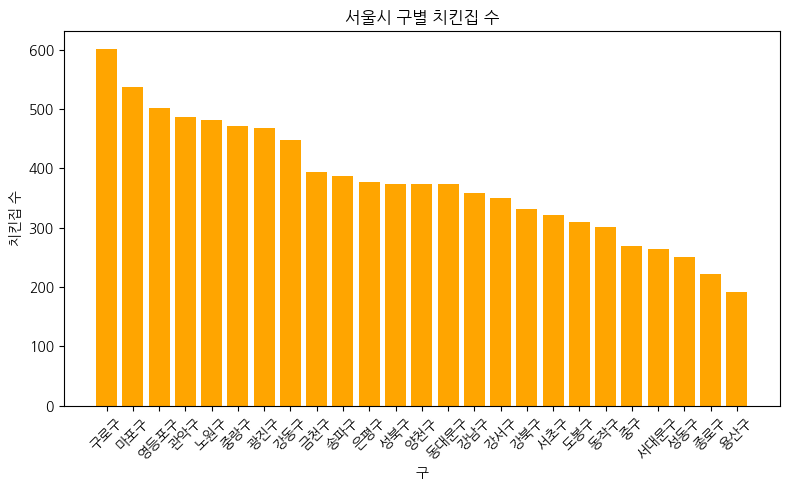

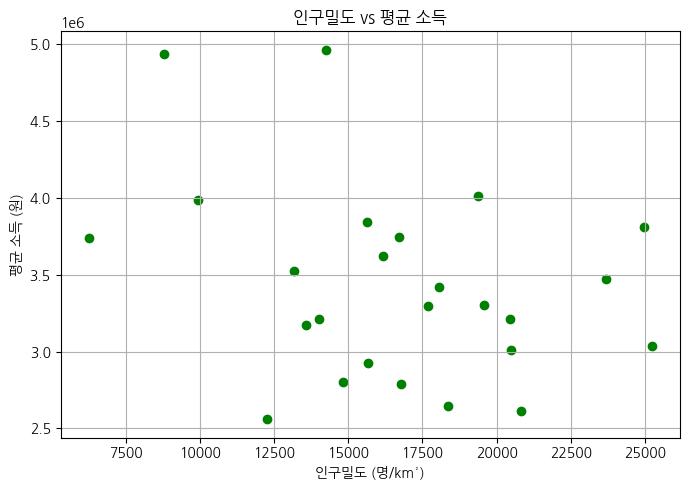

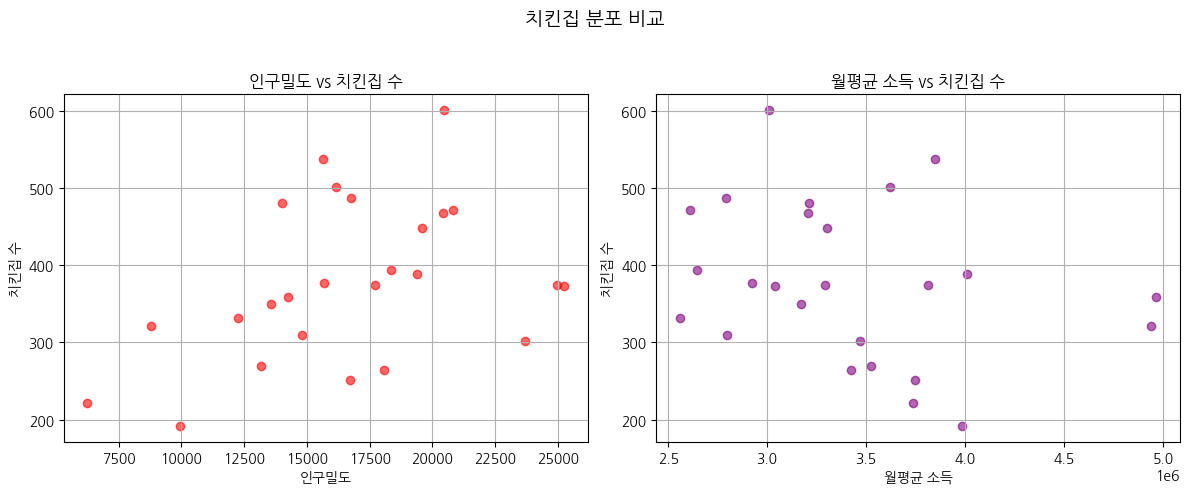

/tmp/ipython-input-30074495.py:65: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_df = df.pivot_table(values='치킨집수',


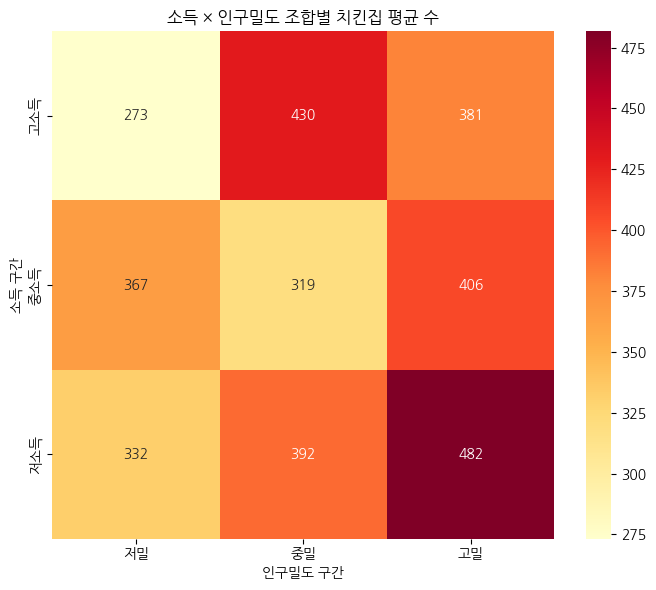

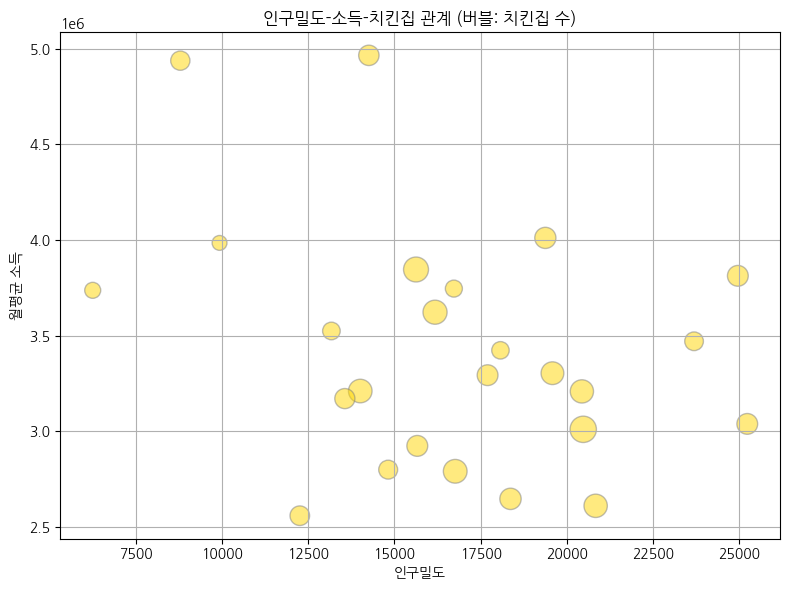

In [6]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import seaborn as sns

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("/content/drive/MyDrive/DnA/서울시_치킨_인구밀도_소득_병합.csv", encoding="utf-8-sig")

# Figure 1: 구별 치킨집 수
plt.figure(figsize=(8,5))
plt.bar(df['구'], df['치킨집수'], color='orange')
plt.title('서울시 구별 치킨집 수')
plt.xlabel('구')
plt.ylabel('치킨집 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Figure 2: 인구밀도 vs 소득 산점도
plt.figure(figsize=(7, 5))
plt.scatter(df['인구밀도'], df['월_평균_소득_금액'], color='green')
plt.title('인구밀도 vs 평균 소득')
plt.xlabel('인구밀도 (명/km²)')
plt.ylabel('평균 소득 (원)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Figure 3: 다중 서브플롯 (인구밀도 / 소득)
fig, axes = plt.subplots(1,2, figsize=(12,5))

axes[0].scatter(df['인구밀도'], df['치킨집수'], alpha=0.6, color='red')
axes[0].set_title('인구밀도 vs 치킨집 수')
axes[0].set_xlabel('인구밀도')
axes[0].set_ylabel('치킨집 수')
axes[0].grid(True)

axes[1].scatter(df['월_평균_소득_금액'], df['치킨집수'], alpha=0.6, color='purple')
axes[1].set_title('월평균 소득 vs 치킨집 수')
axes[1].set_xlabel('월평균 소득')
axes[1].set_ylabel('치킨집 수')
axes[1].grid(True)

plt.suptitle('치킨집 분포 비교', fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# Figure 4: 소득과 인구밀도 구간 나누기
df['소득구간'] = pd.qcut(df['월_평균_소득_금액'], 3,
                     labels=['저소득', '중소득', '고소득'])
df['소득구간'] = pd.Categorical(df['소득구간'],
                     categories=['고소득','중소득','저소득'], ordered=True)

df['밀도구간'] = pd.qcut(df['인구밀도'], 3,
                     labels=['저밀','중밀','고밀'])
df['밀도구간'] = pd.Categorical(df['밀도구간'],
                     categories=['저밀','중밀','고밀'], ordered=True)

pivot_df = df.pivot_table(values='치킨집수',
                          index='소득구간',
                          columns='밀도구간',
                          aggfunc='mean')

plt.figure(figsize=(7, 6))
sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title('소득 × 인구밀도 조합별 치킨집 평균 수')
plt.xlabel('인구밀도 구간')
plt.ylabel('소득 구간')
plt.tight_layout()
plt.show()


# Figure 5: 버블차트
plt.figure(figsize=(8,6))
plt.scatter(df['인구밀도'], df['월_평균_소득_금액'],
            s=df['치킨집수']*0.6, alpha=0.5, color='gold', edgecolors='gray')
plt.title('인구밀도-소득-치킨집 관계 (버블: 치킨집 수)')
plt.xlabel('인구밀도')
plt.ylabel('월평균 소득')
plt.grid(True)
plt.tight_layout()
plt.show()